In [1]:
import os
import numpy as np
import pandas as pd
%matplotlib notebook
import matplotlib.pyplot as plt
import cv2
import glob
import re
import csv
import ipympl


<IPython.core.display.Javascript object>


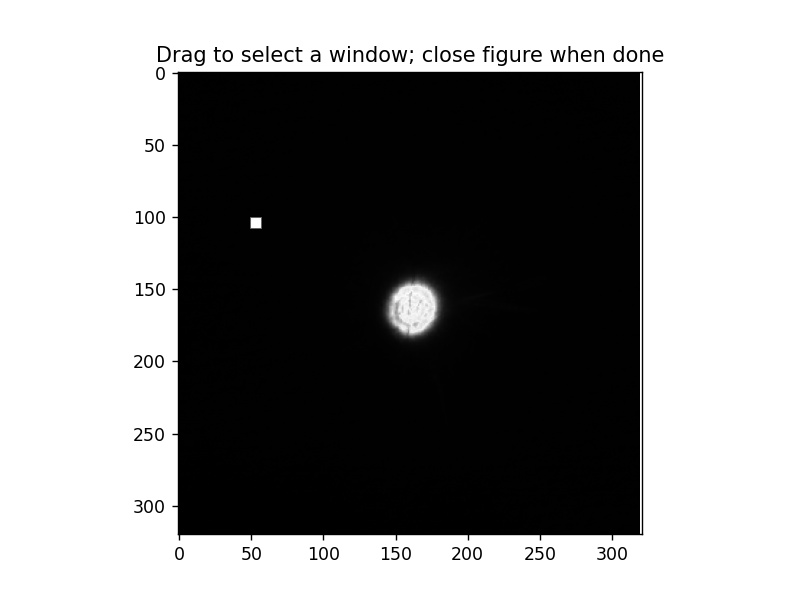

In [5]:
%matplotlib notebook
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector

   r"C:\Users\belco\Documents\Graphene\Data\Data_many_layers"
    r"\2024.06.11_SPR+microscopy on InSb+Gr-12 layaer_197&150 um\197 um"
    r"\01_red laser on the edge_Gr+InSb-up_InSb-down-along lines_0001.ascii.csv"

def extract_coords(folder_paths):
    for folder_path in folder_paths: 
    path = (
 
)
    df = pd.read_csv(folder_path, sep=';', decimal=',', header=None)
    img = df.values


def make_selector(df):
    # This list will collect all the window‐sums
    sums = []
    coords = []
    # Create and display an output widget


    # Plot the image
    fig, ax = plt.subplots()
    ax.imshow(df.values, cmap='gray', origin='upper')
    ax.set_title("Drag to select a window; close figure when done")

    # The callback “closes over” both sums and out
    def onselect(eclick, erelease):
        nonlocal sums
        nonlocal coords
        # get integer pixel coords
        x1, y1 = int(eclick.xdata), int(eclick.ydata)
        x2, y2 = int(erelease.xdata), int(erelease.ydata)
        xmin, xmax = sorted((x1, x2))
        ymin, ymax = sorted((y1, y2))
        coords+=[xmin, ymin, xmax, ymax]
        coords = tuple(coords)
        # sum that window
        total = df.iloc[ymin:ymax+1, xmin:xmax+1].values.sum()
        sums.append(total)
 

        print(f"cols {xmin}→{xmax}, rows {ymin}→{ymax}, sum = {total}")
    # Activate selector
    
    # -------- keep it alive! --------
    selector = RectangleSelector(
        ax, onselect,
        interactive=True,
        button=[1],       # left-click
        minspanx=1, minspany=1
    )
    # -------- keep it alive! --------
    
    plt.show()
    # return all collected sums once the figure is closed
    return sums, coords, selector

# Usage example:
sums, coords, selector = make_selector(df)




In [7]:
print(*coords)

136 104 214 184


In [9]:
# Helper function to extract numeric part from a filename 
def extract_numeric(filename):
    # Use regular expression to find all numeric parts in the filename
    numbers = re.findall(r'\d+', os.path.basename(filename))
    # Convert the list of found numbers to integers and return
    return int(numbers[0]) 

# Conversion of coordinates
def convert_coords(pixel_coords):
    x_pos, width, y_pos, height = pixel_coords
    x1 = (x_pos-width//2) // 80
    y1 = (25600 - y_pos - height//2) // 80
    x2 = (x_pos + width//2) // 80
    y2 = (25600 - y_pos + height//2) // 80
    return (x1, y1, x2, y2)

def process_files(folder_path, ori, pixel_coords, output_file):
    # Get all ASCII files in the folder
    aperture_coords = convert_coords(pixel_coords)
    files = glob.glob(os.path.join(folder_path, '*ascii.csv'))  
    
    # Sort files by numeric elements extracted from the filenames
    files_sorted = sorted(files, key=extract_numeric)

    results = []
    
    for file in files_sorted:
        if 'FEL' in file and ori in file:

            # Read ASCII file with semicolon as separator and treating commas as decimal points
            print(file)
            df = pd.read_csv(file, sep=';', decimal=',', header=None)
        
            # Convert the DataFrame to a NumPy array for easier slicing and summing
            data = df.to_numpy()
        
            # Aperture coordinates (assumed in the format (x1, y1, x2, y2))
            x1, y1, x2, y2 = aperture_coords
        
            # Summing values within the rectangular aperture
            aperture_sum = np.sum(data[y1:y2, x1:x2])
        
            print(f"Sum of aperture in {file}: {aperture_sum}") 
        
            # Visualizing the aperture
            aperture_data = data[y1:y2, x1:x2]
            plt.imshow(aperture_data, cmap='gray', interpolation='none')
            plt.colorbar(label='Data Values')
        
            # Marking the aperture
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='red', facecolor='none', lw=2))
            plt.title(f"Data with Aperture for {os.path.basename(file)}")
            #plt.show()

            # Append the result (filename, aperture_sum)
            results.append([os.path.basename(file), aperture_sum])
    
    # Create a DataFrame and save it to the output file  
    results_df = pd.DataFrame(results, columns=['Filename', 'Aperture Sum'])
    results_df['Gap'] = []
    results_df['IMO'] = []
    results_df['Noise'] = []
    results_df['Norm_In'] = (  (results_df[''] - results_df['Noise'] )/results_df['Exposition']/results_df['IMO'] ) / ()
    results_df['Norm_gr'] = (  (results_df[''] - )/results_df['Noise']/results_df['IMO'] ) / ()
    results_df.to_csv(os.path.join(folder_path, output_file), sep=';', decimal=',', index=False, quoting=csv.QUOTE_MINIMAL, encoding='utf-8-sig')   








# Example usage:
folder_path = r'C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\Data\Data_many_layers\2024.06.11_SPR+microscopy on InSb+Gr-12 layaer_197&150 um\197 um'
pixel_coords = (13946, 3403, 14016, 2413)  # Example aperture coordinates (x1, y1, x2, y2)

process_files(folder_path, 'along', pixel_coords, 'output_along_12_In.ascii')



"""
folder_paths
orientations = '['along', 'trans', 'along', 'trans', 'along', 'trans']
pixel_coords = []
names = []

for i in range(6):
    process_files(folder_paths[i], orientation[i], pixel_coords[i], names[i])


"""


SyntaxError: invalid syntax (2845520696.py, line 63)

интерактивно выделять окошко

In [74]:
# extract noise
folder_path = r"C:\Users\belco\Documents\Graphene\Data\Data_many_layers\2024.06.04_SPR+microscopy on InSb+Gr-6 layaer_197 um"
numbers = glob.glob(os.path.join(folder_path, '*trans*noise*csv'))
numbers

['C:\\Users\\belco\\Documents\\Graphene\\Data\\Data_many_layers\\2024.06.04_SPR+microscopy on InSb+Gr-6 layaer_197 um\\133_FEL beam_InSb+Gr-up_InSb-down-transvers lines_gap-11000 steps_IMO-10_sum-5_noise_0001.ascii.csv']

In [ ]:
    # Create a DataFrame and save it to the output file  
    results_df = pd.DataFrame(results, columns=['Filename', 'Aperture Sum'])
    results_df['Gap'] = 
    results_df['IMO'] = []
    results_df['Noise'] = []
    results_df['Norm_In'] = (  (results_df[''] - )/results_df['Noise']/results_df['IMO'] ) / ()
    results_df['Norm_gr'] = (  (results_df[''] - )/results_df['Noise']/results_df['IMO'] ) / ()
    results_df.to_csv(os.path.join(folder_path, output_file), sep=';', decimal=',', index=False, quoting=csv.QUOTE_MINIMAL, encoding='utf-8-sig')   



In [88]:
fn = "FEL beam_InSb+Gr-up_InSb-down-transvers lines_gap-1000 steps_IMO-10_sum-5_0001.ascii"

In [90]:
sd = re.findall(r'\d+', fn)
print(sd)

['1000', '10', '5', '0001']
